Estimate within-event Granger Causality between pairs of regions around hippocampal and cortical events

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import frites
import xarray as xr
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _regionPEGC(session,regs=None,lim=[-0.5,0.5],bin=0.02,n_shuffle=0,rnd_seed=None):
    # estimate Granger causality (GC) across regions around event peak times as (shuffle, region, lag) XArray
    # surrogate data is produced by circular shift of events, 'shuffle' coordinate is False iff corresponding data values are real

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    firing_rate = R.firingRate(regs=regs,norm=True)
    events = isru.loadHpcPfcEvents(session)

    # GC parameters
    window = 40 # n of samples to estimate one GC value
    lag = 4 # n of past samples used to estimate every value along t
    rng = np.random.default_rng(rnd_seed)
    shift = rng.integers(-5,5,size=(n_shuffle,len(regs))) # shift[i,j] is used to roll region j at shuffle i

    peth = {}
    GC = {}
    names = []
    for name in events:
        GC[name] = None
        if len(events[name]):
            names.append(name)

            p, t, _ = fma.analysis.PETH(firing_rate,events[name],limits=lim,bin=bin)
            print(len(t))
            peth[name] = np.transpose(p,(0,2,1)) # (ripples, region, times)

            t0 = np.arange(0,len(t)-window-1) # samples to start windows
            gc = frites.conn.conn_covgc(peth[name],dt=window,lag=lag,t0=t0,times=t,roi=regs,verbose=False) # (events, region pairs, windows, type)
            GC[name] = [gc]

            # circular shuffle
            n_events, n_regs, n_times = peth[name].shape
            for i in range(n_shuffle):
                idx = (np.arange(n_events)[:,None] - shift[i,:]) % n_events # idx[:,j] shifts the ripple axis for region j
                shifted_peth = peth[name][idx,np.arange(n_regs),:]
                gc = frites.conn.conn_covgc(shifted_peth,dt=window,lag=lag,t0=t0,times=t,roi=regs,verbose=False)
                GC[name].append(gc)

    xdata = {name : xr.DataArray(g,dims=['shuf','e_id','reg','t','dir'],coords={'shuf': [False]+[True]*n_shuffle, 'reg': gc['roi'].values, 't': gc['times'].values,
                'dir': gc['direction'].values, 'rat': int(R.rat)}) if g is not None else None for name, g in GC.items()}

    return xdata, shift

In [3]:
regs = ['hpc','nr','pfc']
session = fma.data.readBatchFile(batch_file)[0][7]
print(f'session: {session}')
xsession, _ = _regionPEGC(session,regs=regs,lim=[-1,1],n_shuffle=1)

session: /mnt/hubel-data-131/perceval/Rat003_20231222/Rat003_20231222.xml
100


/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100
100


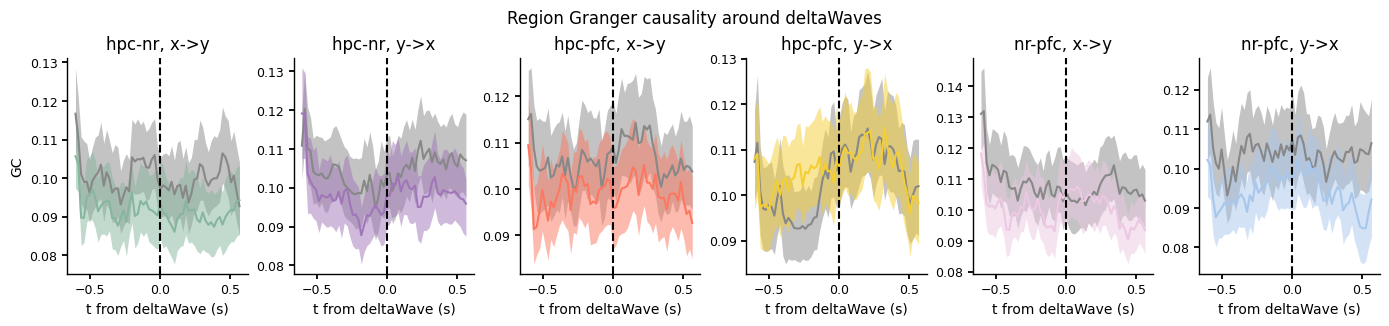

In [6]:
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Region Granger causality around {name}',[1,6],[35,8])
for i, r in enumerate(xsession[name].reg.values):
    reg_data = xsession[name].sel(reg=r)
    for j, d in enumerate(['x->y','y->x']):
        k = 2*i+j
        fma.plotting.semPlot(reg_data.t,reg_data.sel(shuf=True,dir=d),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[k])
        fma.plotting.semPlot(reg_data.t,reg_data.sel(shuf=False,dir=d),zscore=False,color=isru.paperColors(2*i+j),label=r.upper(),ax=axs[k])
        axs[k].set_xlabel(f't from {name[:-1]} (s)'), axs[k].set_title(f'{r}, {d}')
        axs[k].axvline(0,ls='--',color='k')
axs[0].set_ylabel('GC');